In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.figsize": (5, 4),
})


In [42]:
T = 0.03
data_dir = f"T_{T}"
csv_file = os.path.join(data_dir, "pairscatter_points.csv")
df = pd.read_csv(csv_file)
df.head()


,conf_id,sweep,site_idx,re,im
0,conf_1,1,1,-0.009668,-0.004305
1,conf_1,1,2,0.002625,0.043241
2,conf_1,1,3,0.057009,-0.043095
3,conf_1,1,4,0.069325,0.030659
4,conf_1,1,5,0.051614,0.001010


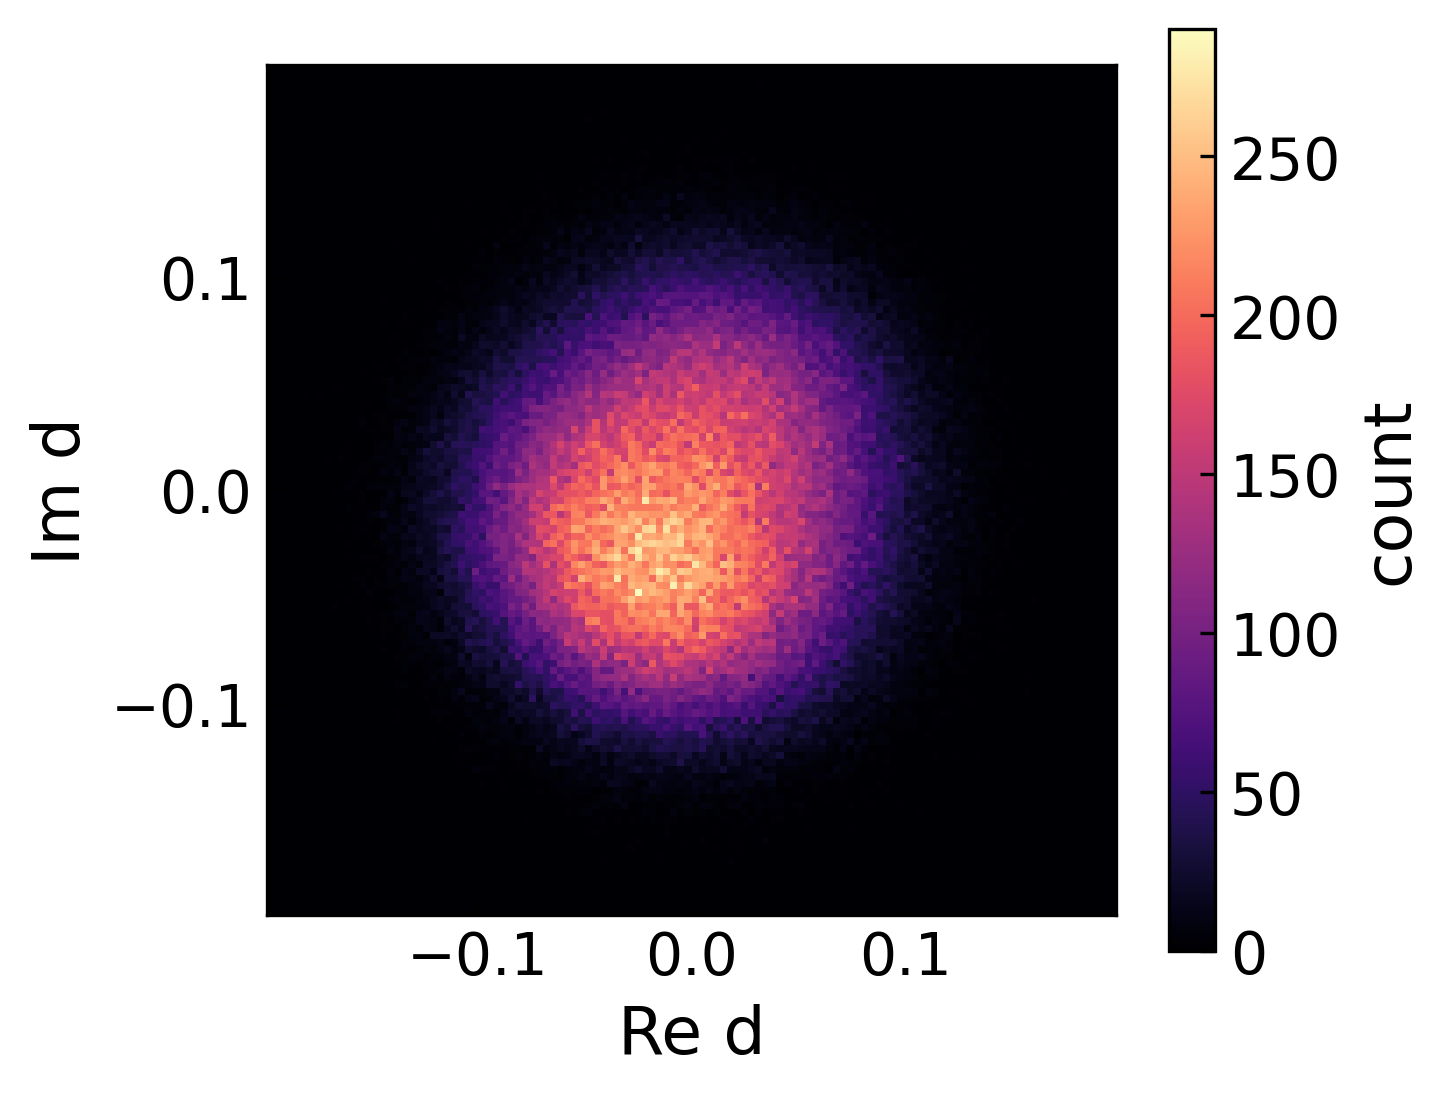

In [43]:
# 2D histogram in complex plane
re = df["re"].to_numpy()
im = df["im"].to_numpy()

n_bins = 120
max_abs = np.max(np.abs(np.concatenate([re, im])))
edges = np.linspace(-max_abs, max_abs, n_bins + 1)

H, xedges, yedges = np.histogram2d(re, im, bins=[edges, edges])

plt.figure(figsize=(5, 4), dpi=300)
pcm = plt.pcolormesh(xedges, yedges, H.T, shading="auto", cmap="magma")
cbar = plt.colorbar(pcm)
cbar.set_label("count")
plt.xlabel("Re d")
plt.ylabel("Im d")
plt.axis("scaled")
plt.tight_layout()
plt.show()


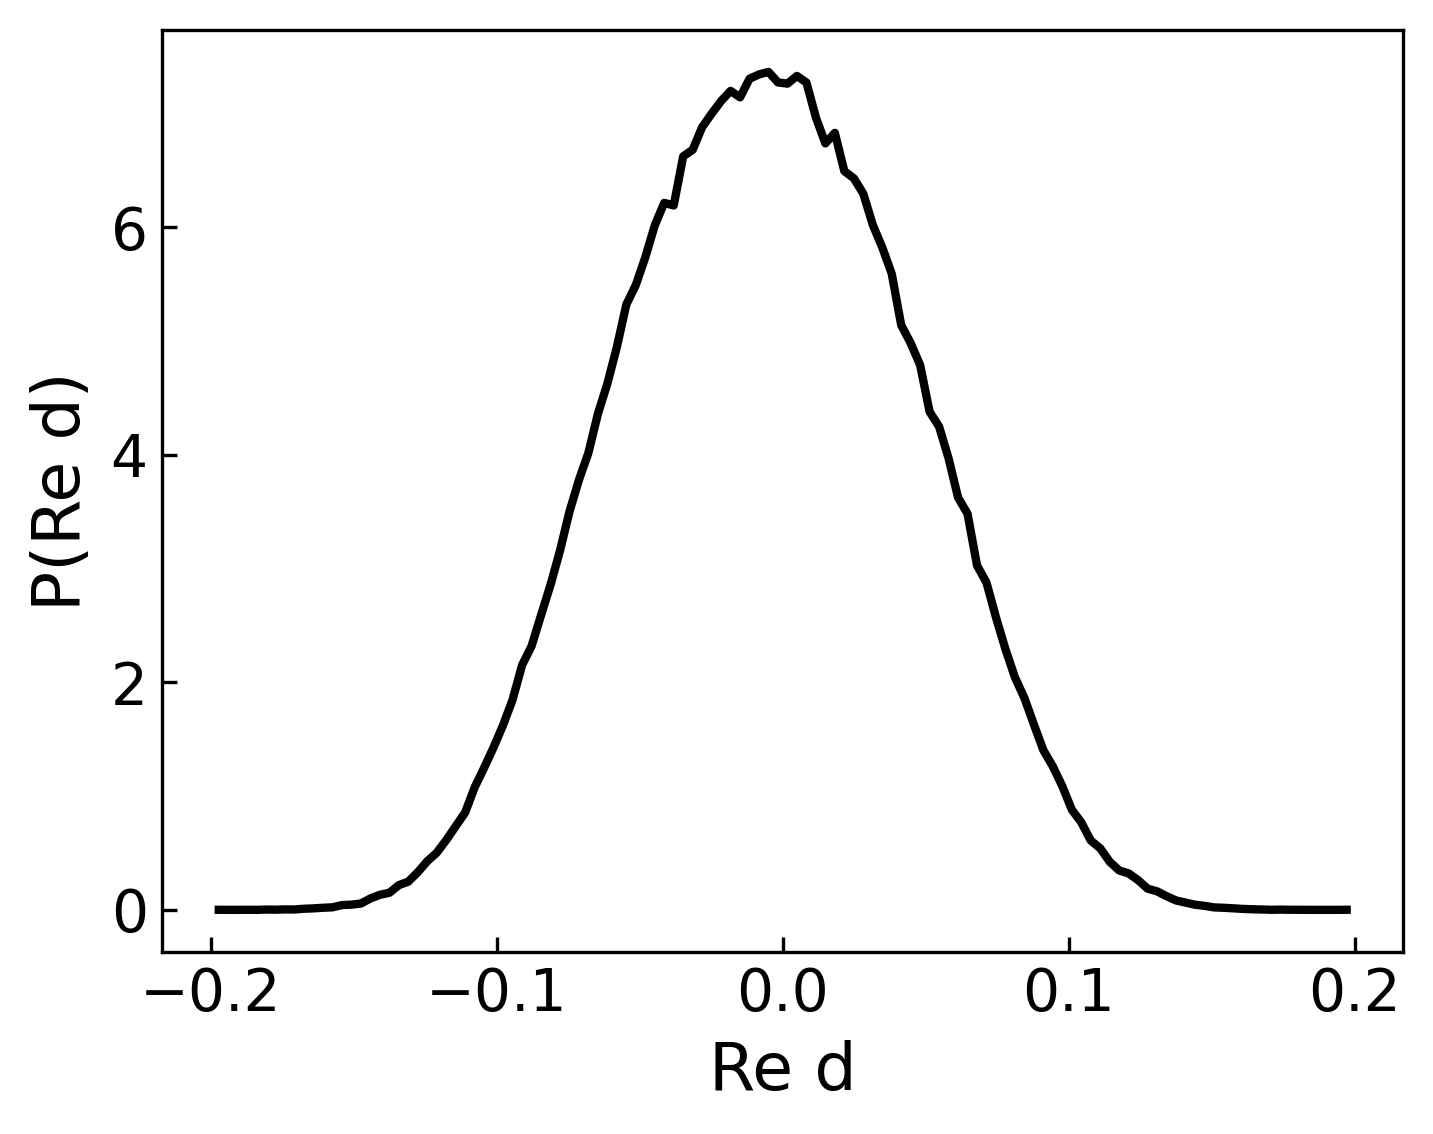

In [44]:
# Re(d) distribution
bins = np.linspace(-max_abs, max_abs, n_bins + 1)
hist, edges = np.histogram(re, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.figure(figsize=(5, 4), dpi=300)
plt.plot(centers, hist, "k-")
plt.xlabel("Re d")
plt.ylabel("P(Re d)")
plt.tight_layout()
plt.show()

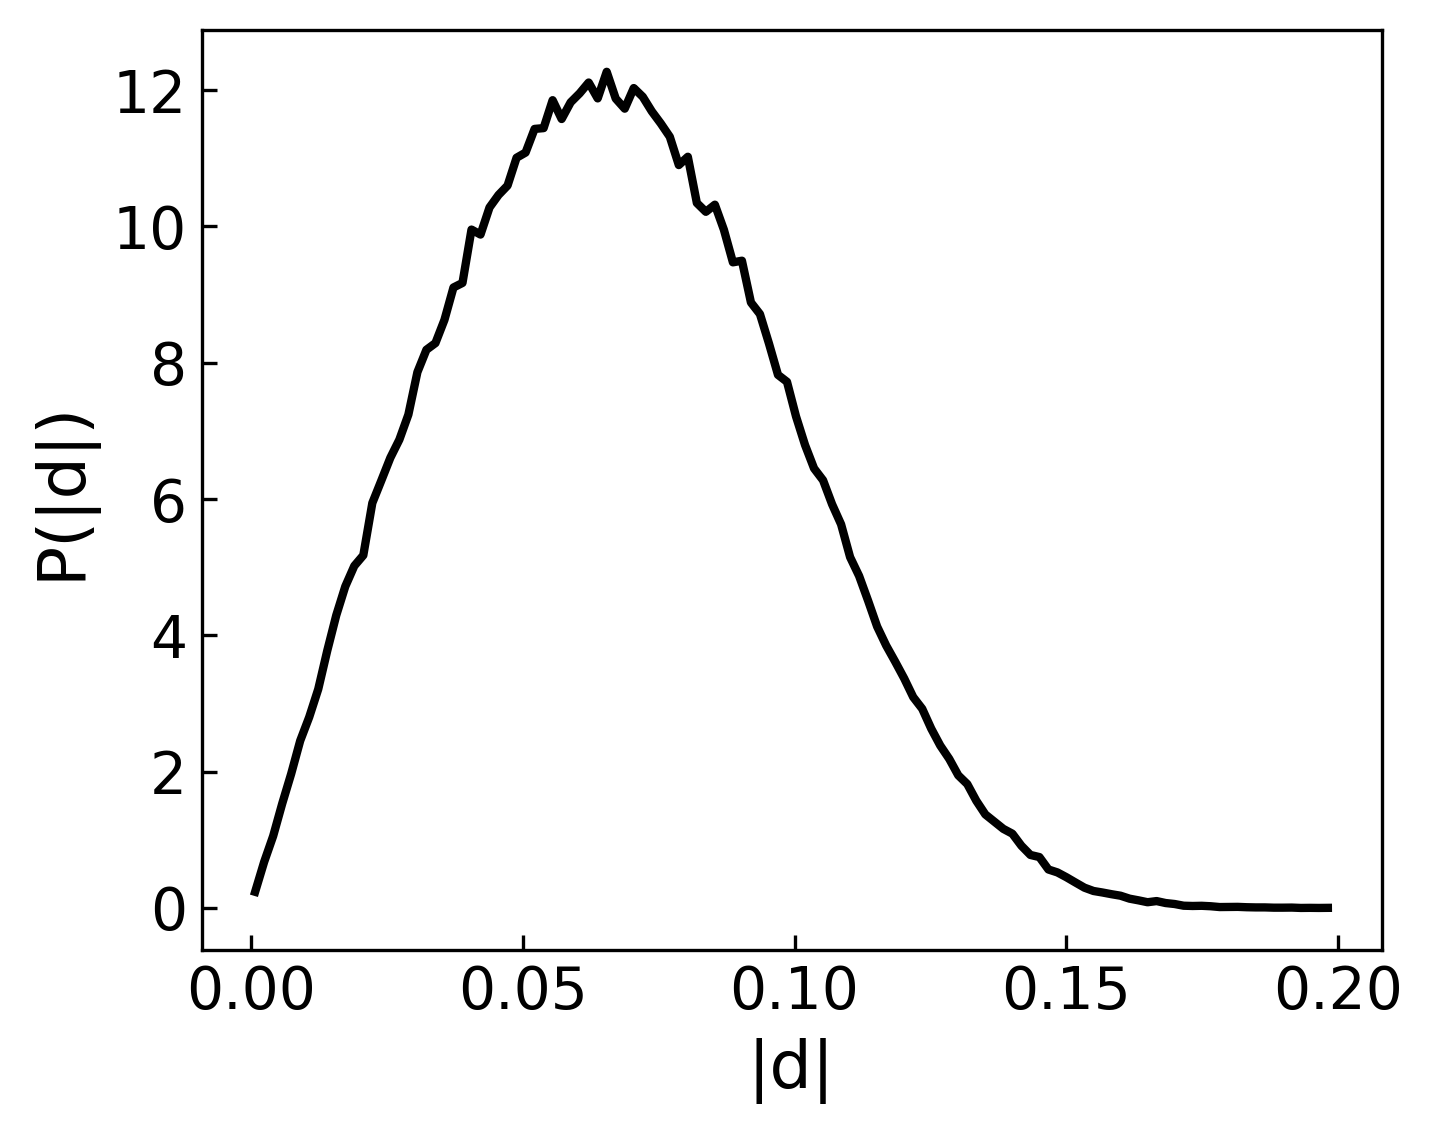

In [45]:
# |d| distribution
r = np.sqrt(re**2 + im**2)
bins = np.linspace(0.0, max_abs, n_bins + 1)
hist, edges = np.histogram(r, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.figure(figsize=(5, 4), dpi=300)
plt.plot(centers, hist, "k-")
plt.xlabel("|d|")
plt.ylabel("P(|d|)")
plt.tight_layout()
plt.show()